# DQN with OpenSpiel 2048

This notebook shows how to train a **Deep Q-Network (DQN)** agent on the [**2048** game](https://2048game.com/) from **OpenSpiel**.

What this notebook covers:
- install and verify dependencies on Google Colab
- inspect the OpenSpiel 2048 API
- build a thin environment wrapper around `pyspiel`
- train a PyTorch DQN with replay buffer and target network
- evaluate the learned policy
- visualize training curves and a greedy rollout

In [2]:
# Colab / notebook setup
# If running on Colab, this cell should work out of the box.

!python -V
# !pip -q install --upgrade pip
# !pip -q install open-spiel torch matplotlib imageio tqdm

Python 3.12.3


In [3]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pyspiel
import torch
import torch.optim as optim
from tqdm.auto import tqdm

print("PyTorch version:", torch.__version__)
print(
    "OpenSpiel version:",
    pyspiel.__version__ if hasattr(pyspiel, "__version__") else "unknown",
)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch version: 2.5.1+cu121
OpenSpiel version: 1.6.12
CUDA available: True
Device: cuda


## 1. Load and inspect OpenSpiel 2048

OpenSpiel represents a game as a `Game` object and a playthrough position as a `State`.
Because **2048 includes randomness**, the tree contains **chance nodes** that we will auto-resolve inside our wrapper.

In [4]:
game = pyspiel.load_game("2048")
state = game.new_initial_state()

game_type = game.get_type()
short_name = game_type.short_name if hasattr(game_type, "short_name") else "2048"

print("Registered game:", short_name)
print("Num distinct actions:", game.num_distinct_actions())
print("Observation tensor shape:", game.observation_tensor_shape())
print("Observation tensor size:", game.observation_tensor_size())
print("Max chance outcomes:", game.max_chance_outcomes())
print("Max game length:", game.max_game_length())
print("Min / Max utility:", game.min_utility(), game.max_utility())
print()
print("Initial state is chance node:", state.is_chance_node())
print("Initial state string:")
print(state)

Registered game: 2048
Num distinct actions: 4
Observation tensor shape: [4, 4]
Observation tensor size: 16
Max chance outcomes: 33
Max game length: 8192
Min / Max utility: 0.0 20480.0

Initial state is chance node: True
Initial state string:
    0    0    0    0
    0    0    0    0
    0    0    0    0
    0    0    0    0



## 2. Helper functions

We use a few robust helpers because OpenSpiel exposes both `observation_tensor(player)` and `observation_tensor()` variants in Python.

In [5]:
from app.helpers import extract_obs, legal_actions, parse_board_numbers, auto_resolve_chance_nodes

# Quick sanity check
test_state = game.new_initial_state()
auto_resolve_chance_nodes(test_state, np.random.default_rng(0))
print(
    "Observation shape after resolving initial chance:", extract_obs(test_state).shape
)
print("Legal actions:", legal_actions(test_state))
print("Board (best effort):")
print(parse_board_numbers(test_state))
print()
print(test_state)

Observation shape after resolving initial chance: (16,)
Legal actions: [0, 1, 2, 3]
Board (best effort):
[[0 0 0 0]
 [2 0 0 0]
 [0 0 2 0]
 [0 0 0 0]]

    0    0    0    0
    2    0    0    0
    0    0    2    0
    0    0    0    0



## 3. A thin OpenSpiel 2048 wrapper

This wrapper:
- auto-resolves chance nodes,
- exposes `reset()` and `step(action)`,
- returns a **flat observation vector**,
- uses **delta in cumulative return** as the immediate reward.

For 2048, the legal action set can shrink because some moves do not change the board.

In [6]:
from app.open_spiel_2048_env import OpenSpiel2048Env


In [7]:
# Demo: random rollout
env = OpenSpiel2048Env(seed=123)
obs = env.reset()

total_reward = 0.0
steps = 0
done = False

while not done and steps < 20:
    a = random.choice(env.legal_actions())
    obs, reward, done, info = env.step(a)
    total_reward += reward
    steps += 1

print("Random steps:", steps)
print("Partial return:", total_reward)
print("Legal actions now:", env.legal_actions())
env.render()

Random steps: 20
Partial return: 128.0
Legal actions now: [0, 1, 2, 3]
    0    2    4    2
    2    0    4    4
    0    0    0   32
    0    0    0    0



## 4. Replay buffer and Q-network

In [8]:
from app.replay_buffer import ReplayBuffer, make_legal_mask
from app.q_network import QNetwork
from app.helpers import masked_greedy_action, epsilon_by_step, dqn_update
from app.eval import greedy_rollout, evaluate_multi_seed, save_eval_results


## 5. Training loop

This is a straightforward DQN:
- replay buffer
- target network
- epsilon-greedy exploration
- legal-action masking
- MSE loss on the Bellman target

Because 2048 is stochastic and can run for many steps, the default training budget below is intentionally moderate for Colab.

In [9]:
# Hyperparameters
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NUM_EPISODES = 300  # increase to 800+ for stronger results
BUFFER_SIZE = 50_000
BATCH_SIZE = 128
GAMMA = 0.99
LR = 1e-3
TARGET_SYNC_EVERY = 250
LEARN_START = 1_000
LEARN_EVERY = 4
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 20_000
MAX_STEPS_PER_EPISODE = 5_000
GRAD_CLIP = 10.0

train_env = OpenSpiel2048Env(seed=SEED)

obs_dim = train_env.obs_dim
num_actions = train_env.num_actions

q_net = QNetwork(obs_dim, num_actions).to(DEVICE)
target_net = QNetwork(obs_dim, num_actions).to(DEVICE)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=LR)
replay = ReplayBuffer(BUFFER_SIZE)

print("obs_dim =", obs_dim)
print("num_actions =", num_actions)

obs_dim = 16
num_actions = 4


In [11]:
episode_returns = []
episode_lengths = []
loss_history = []
eval_returns = []
max_tiles_per_episode = []
illegal_action_attempts = []

global_step = 0

for episode in tqdm(range(1, NUM_EPISODES + 1), desc="Training"):
    obs = train_env.reset(seed=SEED + episode)
    done = False
    ep_return = 0.0
    ep_len = 0
    max_tile = 0  # Track max tile in this episode
    illegal_attempts = 0  # Count illegal action attempts blocked by mask

    while not done and ep_len < MAX_STEPS_PER_EPISODE:
        eps = epsilon_by_step(global_step, eps_start=EPS_START, eps_end=EPS_END, eps_decay_steps=EPS_DECAY_STEPS)
        legal = train_env.legal_actions()
        legal_mask = make_legal_mask(num_actions, legal)

        # Track max tile reached (from observation: 16 flat values)
        # The observation is a flattened 4x4 board
        if obs is not None and len(obs) > 0:
            max_tile = max(max_tile, int(np.max(obs)))

        # Get raw Q-values to detect illegal action selection attempts
        with torch.no_grad():
            q_vals = q_net(torch.tensor(np.asarray([obs]), dtype=torch.float32, device=DEVICE))
            q_vals_np = q_vals.cpu().numpy()[0]

        action = masked_greedy_action(
            q_net=q_net,
            obs=obs,
            legal_actions_list=legal,
            num_actions=num_actions,
            epsilon=eps,
            device=DEVICE,
        )

        # Check if raw network would have picked an illegal action
        if eps > 0 and len(legal) < num_actions:
            best_raw_action = np.argmax(q_vals_np)
            if best_raw_action not in legal:
                illegal_attempts += 1

        next_obs, reward, done, info = train_env.step(action)
        next_legal = info["legal_actions"] if not done else []
        next_legal_mask = make_legal_mask(num_actions, next_legal)

        replay.add(obs, action, reward, next_obs, done, legal_mask, next_legal_mask)

        obs = next_obs
        ep_return += reward
        ep_len += 1
        global_step += 1

        if len(replay) >= LEARN_START and global_step % LEARN_EVERY == 0:
            batch = replay.sample(BATCH_SIZE)
            loss = dqn_update(
                batch=batch,
                q_net=q_net,
                target_net=target_net,
                optimizer=optimizer,
                gamma=GAMMA,
                grad_clip=GRAD_CLIP,
                device=DEVICE,
            )
            loss_history.append(loss)

        if global_step % TARGET_SYNC_EVERY == 0:
            target_net.load_state_dict(q_net.state_dict())

    episode_returns.append(ep_return)
    episode_lengths.append(ep_len)
    max_tiles_per_episode.append(max_tile)
    illegal_action_attempts.append(illegal_attempts)

    if episode % 20 == 0:
        eval_return, eval_len, eval_max_tile, eval_illegal_attempts, _ = greedy_rollout(
            q_net, train_env, num_actions, MAX_STEPS_PER_EPISODE, DEVICE
        )
        eval_returns.append((episode, eval_return))
print("Training complete.")

Training:   0%|          | 0/300 [00:00<?, ?it/s]

Training complete.


## 6. Plot learning curves

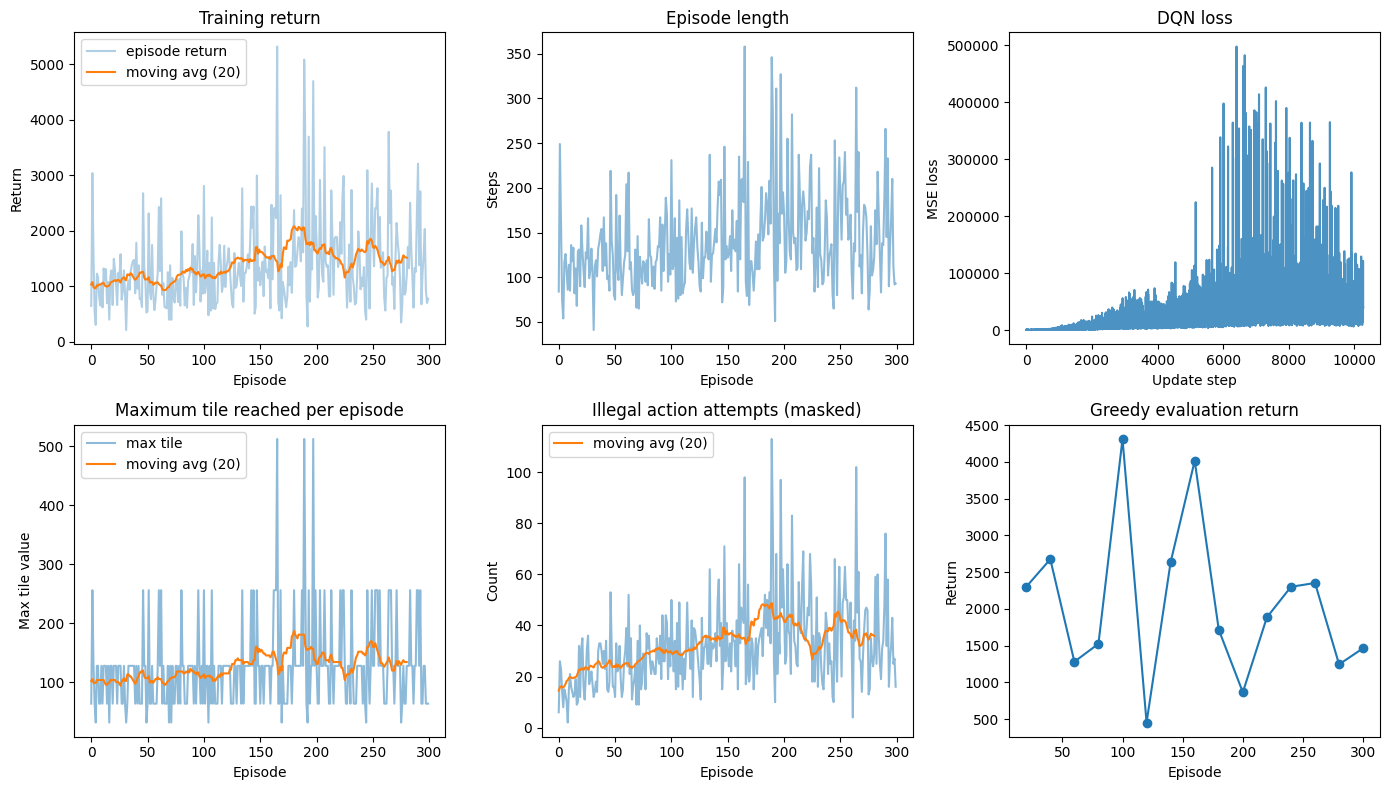

In [12]:
def moving_average(x, w=20):
    if len(x) < w:
        return np.asarray(x)
    return np.convolve(x, np.ones(w) / w, mode="valid")


plt.figure(figsize=(14, 8))

# Original metrics
plt.subplot(2, 3, 1)
plt.plot(episode_returns, alpha=0.35, label="episode return")
ma = moving_average(episode_returns, 20)
plt.plot(range(len(ma)), ma, label="moving avg (20)")
plt.title("Training return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(episode_lengths, alpha=0.5)
plt.title("Episode length")
plt.xlabel("Episode")
plt.ylabel("Steps")

plt.subplot(2, 3, 3)
plt.plot(loss_history, alpha=0.8)
plt.title("DQN loss")
plt.xlabel("Update step")
plt.ylabel("MSE loss")

# New metrics
plt.subplot(2, 3, 4)
plt.plot(max_tiles_per_episode, alpha=0.5, label="max tile")
ma_tiles = moving_average(max_tiles_per_episode, 20)
plt.plot(range(len(ma_tiles)), ma_tiles, label="moving avg (20)")
plt.title("Maximum tile reached per episode")
plt.xlabel("Episode")
plt.ylabel("Max tile value")
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(illegal_action_attempts, alpha=0.5)
ma_illegal = moving_average(illegal_action_attempts, 20)
plt.plot(range(len(ma_illegal)), ma_illegal, label="moving avg (20)")
plt.title("Illegal action attempts (masked)")
plt.xlabel("Episode")
plt.ylabel("Count")
plt.legend()

plt.subplot(2, 3, 6)
if eval_returns:
    eval_eps, eval_vals = zip(*eval_returns)
    plt.plot(eval_eps, eval_vals, marker="o")
    plt.title("Greedy evaluation return")
    plt.xlabel("Episode")
    plt.ylabel("Return")

plt.tight_layout()
plt.show()


### Understanding the 6 Training Metrics

1. **Training Return**
   - Shows the cumulative score achieved in each training episode
   - Raw values are noisy due to randomness; the moving average (20-episode window) shows the trend
   - **Good sign**: Steadily increasing moving average indicates the agent is learning
   - Starts low, gradually improves as the agent discovers winning strategies

2. **Episode Length**
   - Number of steps taken per episode before the game ends
   - **Interpretation**: Higher = agent plays longer before the board fills up
   - Should stabilize as training progresses (agent learns to manage space efficiently)

3. **DQN Loss**
   - Mean Squared Error between predicted and target Q-values during network updates
   - **Good sign**: Loss should generally decrease over training steps
   - High loss early → network is learning; stable/low loss later → convergence

4. **Maximum Tile Reached**
   - Highest tile value created during each episode (e.g., 16, 32, 64, 128...)
   - **Indicator of learning**: Shows progression toward larger merges
   - Should increase over time as agent learns strategic tile management
   - Higher tiles = more points per merge

5. **Illegal Action Attempts**
   - Counts how often the raw Q-network tries to select an illegal action (during exploration)
   - The action mask prevents these from being executed, but frequent attempts = poor convergence
   - **Good sign**: Should decrease to near-zero as training progresses
   - Shows the network is learning valid action patterns

6. **Greedy Evaluation Return**
   - Periodic evaluations (every 20 training episodes) using a greedy policy (ε=0, no exploration)
   - Tests how well the current policy generalizes without relying on randomness
   - **Good sign**: Shows improvement trend; high values = learned an effective strategy
   - Different from training return because it's purely deterministic exploitation

## 7. Evaluate a greedy policy and inspect the final board

In [13]:
eval_env = OpenSpiel2048Env(seed=999)
obs = eval_env.reset(seed=999)

# Execute greedy rollout using reusable eval function
greedy_return, greedy_len, greedy_max_tile, greedy_illegal_attempts, rollout = greedy_rollout(
    q_net=q_net,
    env=eval_env,
    num_actions=num_actions,
    max_steps=MAX_STEPS_PER_EPISODE,
    device=DEVICE,
)

print("Greedy evaluation return:", greedy_return)
print("Rollout length:", greedy_len)
print("Max tile reached:", greedy_max_tile)
print("Greedy illegal action attempts:", greedy_illegal_attempts)
print()
eval_env.render()

Greedy evaluation return: 2900.0
Rollout length: 241
Max tile reached: 256
Greedy illegal action attempts: 70

  256  128   32   16
   32    8    2    8
    4   16    8    4
    2    8    4    2



In [14]:
# Show a few last boards from the greedy rollout
n_show = min(5, len(rollout))
for i, step_info in enumerate(rollout[-n_show:], start=len(rollout) - n_show + 1):
    print("=" * 60)
    print(f"Step {i} | action={step_info['action']} | reward={step_info['reward']:.1f}")
    if step_info["board"] is not None:
        print(step_info["board"])
    if step_info["state_text"] is not None:
        print(step_info["state_text"])


Step 237 | action=3 | reward=4.0
[[256 128  32  16]
 [ 32   8   2   8]
 [  2  16   8   4]
 [  4   4   2   0]]
  256  128   32   16
   32    8    2    8
    2   16    8    4
    4    4    2    0

Step 238 | action=3 | reward=8.0
[[256 128  32  16]
 [ 32   8   2   8]
 [  2  16   8   4]
 [  8   2   0   2]]
  256  128   32   16
   32    8    2    8
    2   16    8    4
    8    2    0    2

Step 239 | action=3 | reward=4.0
[[256 128  32  16]
 [ 32   8   2   8]
 [  2  16   8   4]
 [  8   4   2   0]]
  256  128   32   16
   32    8    2    8
    2   16    8    4
    8    4    2    0

Step 240 | action=1 | reward=0.0
[[256 128  32  16]
 [ 32   8   2   8]
 [  2  16   8   4]
 [  2   8   4   2]]
  256  128   32   16
   32    8    2    8
    2   16    8    4
    2    8    4    2

Step 241 | action=0 | reward=4.0
[[256 128  32  16]
 [ 32   8   2   8]
 [  4  16   8   4]
 [  2   8   4   2]]
  256  128   32   16
   32    8    2    8
    4   16    8    4
    2    8    4    2



In [15]:
# Multi-seed evaluation using reusable eval module
print("=" * 60)
print("Multi-seed evaluation of greedy policy")
print("=" * 60)

num_eval_seeds = 100
output_dir = "./output/dqn"

# Run multi-seed evaluation
eval_data = evaluate_multi_seed(
    q_net=q_net,
    env_class=OpenSpiel2048Env,
    num_eval_seeds=num_eval_seeds,
    num_actions=num_actions,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    device=DEVICE,
    seed_offset=5000,
)

# Save results
npz_path, json_path = save_eval_results(
    eval_data=eval_data,
    output_dir=output_dir,
    num_actions=num_actions,
    obs_dim=obs_dim,
    source_notebook="Baseline DQN",
    checkpoint_file="dqn.pt",
)

# Print summary
summary = eval_data["summary"]
avg_return = summary["avg_return"]
std_return = summary["std_return"]
avg_length = summary["avg_length"]
avg_max_tile = summary["avg_max_tile"]
avg_illegal_attempts = summary["avg_illegal_action_attempts"]
total_illegal_attempts = summary["total_illegal_action_attempts"]
multi_seed_returns = eval_data["episode_returns"].tolist()
multi_seed_max_tiles = eval_data["max_tiles"].tolist()
multi_seed_illegal_attempts = eval_data["episode_illegal_action_attempts"].tolist()

print(f"\nSaved evaluation rollout archive to: {npz_path}")
print(f"Saved evaluation metadata to: {json_path}")
print(f"Saved {len(eval_data['actions'])} transitions across {num_eval_seeds} evaluation episodes.")

print(f"\nResults over {num_eval_seeds} seeds:")
print(f"  Average return:           {avg_return:.1f} +- {std_return:.1f}")
print(f"  Average episode length:   {avg_length:.1f}")
print(f"  Average max tile:         {avg_max_tile:.1f}")
print(f"  Average illegal attempts: {avg_illegal_attempts:.1f}")
print(f"  Total illegal attempts:   {total_illegal_attempts}")
print(f"\nPer-seed returns: {[f'{r:.1f}' for r in multi_seed_returns]}")
print(f"Per-seed max tiles: {[f'{t:.0f}' for t in multi_seed_max_tiles]}")
print(f"Per-seed illegal attempts: {multi_seed_illegal_attempts}")

Multi-seed evaluation of greedy policy

Saved evaluation rollout archive to: ./output/dqn/eval_rollout.npz
Saved evaluation metadata to: ./output/dqn/eval_meta.json
Saved 21504 transitions across 100 evaluation episodes.

Results over 100 seeds:
  Average return:           2461.5 +- 1378.5
  Average episode length:   215.0
  Average max tile:         203.5
  Average illegal attempts: 58.7
  Total illegal attempts:   5871

Per-seed returns: ['1716.0', '5168.0', '4120.0', '2296.0', '984.0', '1392.0', '2796.0', '3140.0', '1304.0', '3232.0', '516.0', '2716.0', '1016.0', '1408.0', '1508.0', '1804.0', '1388.0', '3992.0', '576.0', '2876.0', '3200.0', '3252.0', '1124.0', '2360.0', '3240.0', '5384.0', '1768.0', '2040.0', '2172.0', '1628.0', '3556.0', '600.0', '804.0', '1688.0', '3348.0', '3144.0', '3164.0', '1904.0', '1476.0', '5596.0', '2060.0', '3320.0', '736.0', '1420.0', '1468.0', '2188.0', '1304.0', '3472.0', '3416.0', '2764.0', '1464.0', '1296.0', '2316.0', '4624.0', '1412.0', '3252.0', '

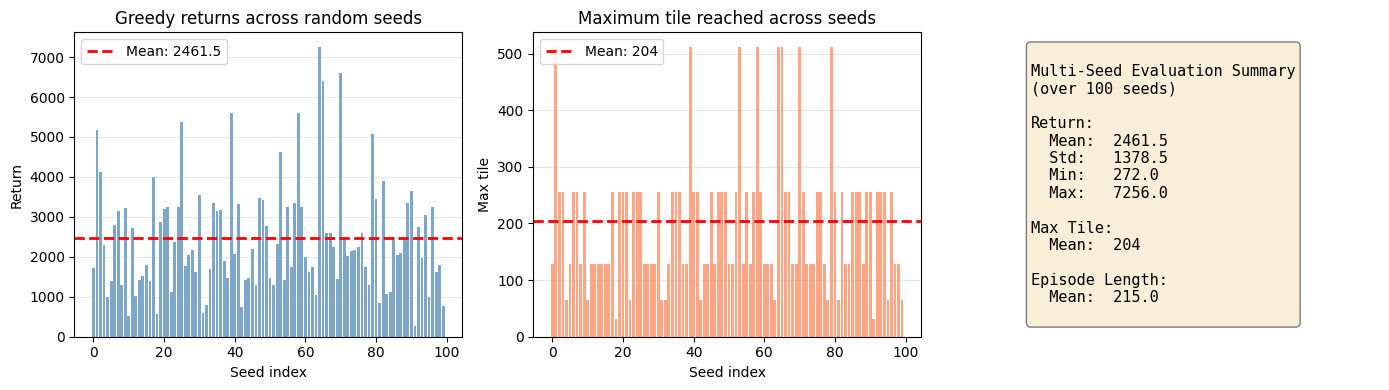

In [16]:
# Visualize multi-seed evaluation results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribution of returns across seeds
axes[0].bar(range(num_eval_seeds), multi_seed_returns, color='steelblue', alpha=0.7)
axes[0].axhline(y=avg_return, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_return:.1f}')
axes[0].set_xlabel('Seed index')
axes[0].set_ylabel('Return')
axes[0].set_title('Greedy returns across random seeds')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Distribution of max tiles across seeds
axes[1].bar(range(num_eval_seeds), multi_seed_max_tiles, color='coral', alpha=0.7)
axes[1].axhline(y=avg_max_tile, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_max_tile:.0f}')
axes[1].set_xlabel('Seed index')
axes[1].set_ylabel('Max tile')
axes[1].set_title('Maximum tile reached across seeds')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Summary statistics
stats_text = f"""
Multi-Seed Evaluation Summary
(over {num_eval_seeds} seeds)

Return:
  Mean:  {avg_return:.1f}
  Std:   {std_return:.1f}
  Min:   {min(multi_seed_returns):.1f}
  Max:   {max(multi_seed_returns):.1f}

Max Tile:
  Mean:  {avg_max_tile:.0f}

Episode Length:
  Mean:  {avg_length:.1f}
"""
axes[2].text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center',
            family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 8. Save the model

You can download this checkpoint from Colab or store it to Google Drive.

In [17]:
eval_env = OpenSpiel2048Env(seed=999)
obs = eval_env.reset(seed=999)

# Execute greedy rollout using reusable eval function
greedy_return, greedy_len, greedy_max_tile, greedy_illegal_attempts, rollout = greedy_rollout(
    q_net=q_net,
    env=eval_env,
    num_actions=num_actions,
    max_steps=MAX_STEPS_PER_EPISODE,
    device=DEVICE,
)

print("Greedy evaluation return:", greedy_return)
print("Rollout length:", greedy_len)
print("Max tile reached:", greedy_max_tile)
print("Greedy illegal action attempts:", greedy_illegal_attempts)
print()
eval_env.render()

Greedy evaluation return: 2900.0
Rollout length: 241
Max tile reached: 256
Greedy illegal action attempts: 70

  256  128   32   16
   32    8    2    8
    4   16    8    4
    2    8    4    2



## 9. Suggested extensions for students

1. Replace vanilla DQN with **Double DQN**.
2. Add **dueling heads**.
3. Compare **delta-return reward** versus raw `state.rewards()`.
4. Try a different state encoding if you decode the board more explicitly.
5. Track additional metrics such as:
   - maximum tile reached,
   - fraction of illegal actions avoided,
   - average greedy return over multiple seeds.